# XGBoost Robustness Analysis
### Chronological (out-of-time) validation, Leave-One-Month-Out CV, grid-search tuning, native TreeSHAP tracking, and bootstrap confidence intervals

**Purpose.** Companion to `05_LogisticRegression_Robustness.ipynb` and `06_RandomForest_Robustness.ipynb`, completing the three-model out-of-time picture for **XGBoost**. It re-evaluates the model previously fit in `XGboost.ipynb` under:

1. **Out-of-time (chronological) holdout** — train on Feb-Sep, test on Oct-Nov-Dec.
2. **Leave-One-Month-Out (LOMO) cross-validation** — each month held out in turn, tracking performance and `Month_Nov`'s SHAP-importance rank per fold.

This also closes two items from Jenni's Part B: **XGBoost hyperparameter tuning** (previously unspecified in the manuscript) and, together with `06_RandomForest_Robustness.ipynb`, the cross-architecture Rashomon comparison under a matched out-of-time protocol.

SHAP values are computed with XGBoost's **native TreeSHAP** (`booster.predict(..., pred_contribs=True)`), exactly as in `XGboost.ipynb` — no separate `shap` library call is required for the contribution values themselves, keeping this notebook runnable even in environments where only `xgboost` (not `shap`) is installed.

**This notebook does not modify or overwrite `XGboost.ipynb`.** All outputs use an `xgb_` prefix.

> As with the other two robustness notebooks: `Month_Oct`/`Month_Nov`/`Month_Dec` are constant in the chronological training partition, so that split reports **aggregate predictive performance only**. `Month_Nov`'s SHAP-rank stability is assessed via LOMO.

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, roc_auc_score, average_precision_score,
    f1_score, matthews_corrcoef, precision_score, recall_score,
    brier_score_loss, confusion_matrix
)

from xgboost import XGBClassifier
import xgboost as xgb

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

MONTH_ORDER = ["Feb", "Mar", "May", "June", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]


In [15]:
def expected_calibration_error(y_true, y_prob, n_bins=10):
    y_true = np.asarray(y_true); y_prob = np.asarray(y_prob)
    bins = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    N = len(y_true)
    for i in range(n_bins):
        lo, hi = bins[i], bins[i + 1]
        mask = (y_prob >= lo) & (y_prob <= hi) if i == n_bins - 1 else (y_prob >= lo) & (y_prob < hi)
        n = mask.sum()
        if n == 0:
            continue
        ece += (n / N) * abs(y_true[mask].mean() - y_prob[mask].mean())
    return ece


def evaluate_clf(model, X_te_s, y_te, label):
    y_pred = model.predict(X_te_s)
    y_prob = model.predict_proba(X_te_s)[:, 1]
    return {
        "Split": label,
        "N_test": int(len(y_te)),
        "Accuracy": round(accuracy_score(y_te, y_pred), 4),
        "ROC_AUC": round(roc_auc_score(y_te, y_prob), 4),
        "PR_AUC": round(average_precision_score(y_te, y_prob), 4),
        "F1": round(f1_score(y_te, y_pred), 4),
        "MCC": round(matthews_corrcoef(y_te, y_pred), 4),
        "Precision": round(precision_score(y_te, y_pred), 4),
        "Recall": round(recall_score(y_te, y_pred), 4),
        "Brier": round(brier_score_loss(y_te, y_prob), 4),
        "ECE": round(expected_calibration_error(y_te.to_numpy(), y_prob), 4),
    }


def xgb_shap_importance(fitted_model, X_te_s_df):
    """Native TreeSHAP via the underlying booster, matching XGboost.ipynb's approach."""
    dtest = xgb.DMatrix(X_te_s_df)
    booster = fitted_model.get_booster()
    contribs = booster.predict(dtest, pred_contribs=True)
    shap_values = contribs[:, :-1]   # last column is the bias / base-value term
    mean_abs_shap = np.abs(shap_values).mean(axis=0)
    imp = pd.DataFrame({
        "feature": X_te_s_df.columns,
        "mean_abs_shap": mean_abs_shap
    }).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)
    imp["rank"] = imp.index + 1
    return imp


In [16]:
df = pd.read_csv("online_shoppers_intention.csv")
assert set(df["Month"].unique()) == set(MONTH_ORDER), \
    "MONTH_ORDER does not match the months present in the data - check for a schema change."

NOMINAL_INT_COLS = ["OperatingSystems", "Browser", "Region", "TrafficType"]
df[NOMINAL_INT_COLS] = df[NOMINAL_INT_COLS].astype("category")

df_encoded = pd.get_dummies(df, drop_first=True, dtype=int)
y = df_encoded["Revenue"]
X = df_encoded.drop("Revenue", axis=1)
X = X.drop(columns=["PageValues", "BounceRates", "ExitRates"])

month_rank_map = {m: i for i, m in enumerate(MONTH_ORDER)}

print("X shape:", X.shape)


X shape: (12330, 65)


## 1. Out-of-time (chronological) split

In [17]:
TEST_MONTHS = ["Oct", "Nov", "Dec"]

train_mask = ~df["Month"].isin(TEST_MONTHS)
test_mask = df["Month"].isin(TEST_MONTHS)

X_train_chrono, X_test_chrono = X[train_mask], X[test_mask]
y_train_chrono, y_test_chrono = y[train_mask], y[test_mask]

train_months_present = sorted(df.loc[train_mask, "Month"].unique(), key=lambda m: month_rank_map[m])
print(f"Chronological split - train: {X_train_chrono.shape[0]} sessions, months: {train_months_present}")
print(f"Chronological split - test:  {X_test_chrono.shape[0]} sessions, months: {TEST_MONTHS}")

neg_chrono, pos_chrono = (y_train_chrono == 0).sum(), (y_train_chrono == 1).sum()
scale_pos_weight_chrono = neg_chrono / pos_chrono
print(f"scale_pos_weight (train class ratio): {scale_pos_weight_chrono:.4f}")


Chronological split - train: 7056 sessions, months: ['Feb', 'Mar', 'May', 'June', 'Jul', 'Aug', 'Sep']
Chronological split - test:  5274 sessions, months: ['Oct', 'Nov', 'Dec']
scale_pos_weight (train class ratio): 7.6365


### 1.1 Hyperparameter tuning (inner 5-fold grid search, chronological training partition only)

`scale_pos_weight` is fixed to the training-set negative-to-positive class ratio (not grid-searched) so class weighting stays consistent with the treatment already applied to Logistic Regression and Random Forest; the grid searches over the remaining architecture-specific hyperparameters, matching the original `XGboost.ipynb` configuration (`n_estimators=300, max_depth=6, learning_rate=0.1, subsample=0.9, colsample_bytree=0.9`) as its center point.

In [18]:
scaler_chrono = StandardScaler()
X_train_chrono_s = scaler_chrono.fit_transform(X_train_chrono)
X_test_chrono_s = scaler_chrono.transform(X_test_chrono)

param_grid = {
    "n_estimators": [200, 300, 500],
    "max_depth": [4, 6, 8],
    "learning_rate": [0.05, 0.1, 0.2],
    "subsample": [0.8, 0.9],
    "colsample_bytree": [0.8, 0.9],
}
inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

base_estimator = XGBClassifier(
    scale_pos_weight=scale_pos_weight_chrono,
    base_score=0.5,
    eval_metric="logloss",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

grid_search = GridSearchCV(
    estimator=base_estimator,
    param_grid=param_grid,
    scoring="average_precision",
    cv=inner_cv,
    n_jobs=-1,
)
grid_search.fit(X_train_chrono_s, y_train_chrono)

best_params = grid_search.best_params_
print("Selected XGBoost hyperparameters (inner 5-fold, scoring = PR-AUC):", best_params)

cv_grid_df = pd.DataFrame(grid_search.cv_results_)[
    ["params", "mean_test_score", "std_test_score", "rank_test_score"]
].sort_values("rank_test_score")
cv_grid_df.to_csv("xgb_gridsearch_chronological.csv", index=False)
cv_grid_df.head(10)


c:\Users\ASUS\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\model_selection\_search.py:1135: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(


Selected XGBoost hyperparameters (inner 5-fold, scoring = PR-AUC): {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 200, 'subsample': 0.8}


,params,mean_test_score,std_test_score,rank_test_score
0,"{'colsample_bytree': 0.8, 'learning_rate': 0.0...",NaN,NaN,1
1,"{'colsample_bytree': 0.8, 'learning_rate': 0.0...",NaN,NaN,1
2,"{'colsample_bytree': 0.8, 'learning_rate': 0.0...",NaN,NaN,1
3,"{'colsample_bytree': 0.8, 'learning_rate': 0.0...",NaN,NaN,1
4,"{'colsample_bytree': 0.8, 'learning_rate': 0.0...",NaN,NaN,1
5,"{'colsample_bytree': 0.8, 'learning_rate': 0.0...",NaN,NaN,1
6,"{'colsample_bytree': 0.8, 'learning_rate': 0.0...",NaN,NaN,1
7,"{'colsample_bytree': 0.8, 'learning_rate': 0.0...",NaN,NaN,1
8,"{'colsample_bytree': 0.8, 'learning_rate': 0.0...",NaN,NaN,1
9,"{'colsample_bytree': 0.8, 'learning_rate': 0.0...",NaN,NaN,1


### 1.2 Evaluate the tuned model on the chronological holdout

In [19]:
xgb_chrono = grid_search.best_estimator_

chrono_result = evaluate_clf(xgb_chrono, X_test_chrono_s, y_test_chrono,
                              f"Chronological (train={train_months_present}, test={TEST_MONTHS})")
chrono_result.update({f"Selected_{k}": v for k, v in best_params.items()})
chrono_result["scale_pos_weight"] = round(scale_pos_weight_chrono, 4)
chrono_result_df = pd.DataFrame([chrono_result])
chrono_result_df.to_csv("xgb_chronological_holdout_results.csv", index=False)
chrono_result_df


,Split,N_test,Accuracy,ROC_AUC,PR_AUC,F1,MCC,Precision,Recall,Brier,ECE,Selected_colsample_bytree,Selected_learning_rate,Selected_max_depth,Selected_n_estimators,Selected_subsample,scale_pos_weight
0,"Chronological (train=['Feb', 'Mar', 'May', 'Ju...",5274,0.5491,0.6352,0.2947,0.3752,0.1427,0.263,0.6544,0.2491,0.2638,0.8,0.05,4,200,0.8,7.6365


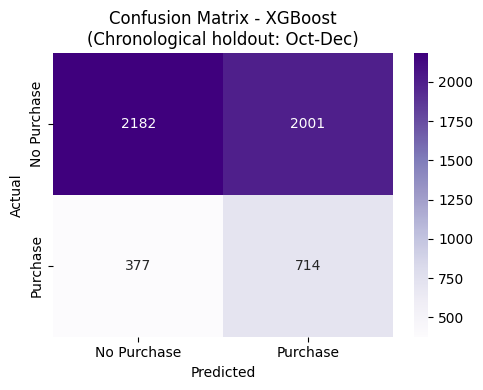

In [20]:
y_pred_chrono = xgb_chrono.predict(X_test_chrono_s)
cm_chrono = confusion_matrix(y_test_chrono, y_pred_chrono)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_chrono, annot=True, fmt="d", cmap="Purples",
            xticklabels=["No Purchase", "Purchase"],
            yticklabels=["No Purchase", "Purchase"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - XGBoost\n(Chronological holdout: Oct-Dec)")
plt.tight_layout()
plt.savefig("xgb_confusion_matrix_chronological.png", dpi=200, bbox_inches="tight")
plt.show()


### 1.3 Native TreeSHAP feature importance on the chronological holdout

In [21]:
X_test_chrono_s_df = pd.DataFrame(X_test_chrono_s, columns=X.columns)
shap_importance_chrono = xgb_shap_importance(xgb_chrono, X_test_chrono_s_df)
shap_importance_chrono.to_csv("xgb_chronological_shap_importance.csv", index=False)

shap_importance_chrono.head(15)


,feature,mean_abs_shap,rank
0,ProductRelated_Duration,0.544259,1
1,ProductRelated,0.245861,2
2,VisitorType_Returning_Visitor,0.218309,3
3,Administrative_Duration,0.170830,4
4,Administrative,0.160049,5
5,TrafficType_2,0.123731,6
6,Month_Mar,0.106073,7
7,Informational_Duration,0.092674,8
8,OperatingSystems_3,0.092545,9
9,TrafficType_3,0.084041,10


## 2. Leave-One-Month-Out (LOMO) cross-validation

Each month is held out in turn; the model is refit on the remaining months (using the tuned hyperparameters selected above, with `scale_pos_weight` recomputed per fold from that fold's own training class ratio), and evaluated on the held-out month.

In [22]:
months_present = df["Month"].unique().tolist()

lomo_results = []
lomo_shap_records = []

for held_out_month in MONTH_ORDER:
    if held_out_month not in months_present:
        continue

    train_mask_m = df["Month"] != held_out_month
    test_mask_m = df["Month"] == held_out_month

    X_train_m, X_test_m = X[train_mask_m], X[test_mask_m]
    y_train_m, y_test_m = y[train_mask_m], y[test_mask_m]

    scaler_m = StandardScaler()
    X_train_m_s = scaler_m.fit_transform(X_train_m)
    X_test_m_s = scaler_m.transform(X_test_m)

    neg_m, pos_m = (y_train_m == 0).sum(), (y_train_m == 1).sum()
    scale_pos_weight_m = neg_m / pos_m

    xgb_m = XGBClassifier(
        n_estimators=best_params["n_estimators"],
        max_depth=best_params["max_depth"],
        learning_rate=best_params["learning_rate"],
        subsample=best_params["subsample"],
        colsample_bytree=best_params["colsample_bytree"],
        scale_pos_weight=scale_pos_weight_m,
        base_score=0.5,
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    xgb_m.fit(X_train_m_s, y_train_m)

    row = evaluate_clf(xgb_m, X_test_m_s, y_test_m, f"LOMO holdout: {held_out_month}")
    row["Held_out_month"] = held_out_month
    lomo_results.append(row)

    X_test_m_s_df = pd.DataFrame(X_test_m_s, columns=X.columns)
    shap_imp_m = xgb_shap_importance(xgb_m, X_test_m_s_df)
    shap_imp_m["Held_out_month"] = held_out_month
    lomo_shap_records.append(shap_imp_m)

    print(f"Completed LOMO fold: held out {held_out_month} (n_test={len(y_test_m)})")

lomo_results_df = pd.DataFrame(lomo_results)
lomo_results_df = lomo_results_df[["Held_out_month"] + [c for c in lomo_results_df.columns if c != "Held_out_month"]]
lomo_results_df.to_csv("xgb_lomo_results.csv", index=False)
lomo_results_df


Completed LOMO fold: held out Feb (n_test=184)
Completed LOMO fold: held out Mar (n_test=1907)
Completed LOMO fold: held out May (n_test=3364)
Completed LOMO fold: held out June (n_test=288)
Completed LOMO fold: held out Jul (n_test=432)
Completed LOMO fold: held out Aug (n_test=433)
Completed LOMO fold: held out Sep (n_test=448)
Completed LOMO fold: held out Oct (n_test=549)
Completed LOMO fold: held out Nov (n_test=2998)
Completed LOMO fold: held out Dec (n_test=1727)


,Held_out_month,Split,N_test,Accuracy,ROC_AUC,PR_AUC,F1,MCC,Precision,Recall,Brier,ECE
0,Feb,LOMO holdout: Feb,184,0.9293,0.8085,0.0526,0.0000,-0.0309,0.0000,0.0000,0.0777,0.1949
1,Mar,LOMO holdout: Mar,1907,0.7016,0.7790,0.2634,0.3282,0.2681,0.2122,0.7240,0.1807,0.2932
2,May,LOMO holdout: May,3364,0.7417,0.7716,0.2789,0.3331,0.2456,0.2313,0.5945,0.1623,0.2538
3,June,LOMO holdout: June,288,0.6806,0.6971,0.2098,0.2333,0.1200,0.1538,0.4828,0.1769,0.2671
4,Jul,LOMO holdout: Jul,432,0.6829,0.6605,0.2562,0.3184,0.1579,0.2370,0.4848,0.1920,0.2364
5,Aug,LOMO holdout: Aug,433,0.6028,0.6233,0.2905,0.3008,0.0890,0.2176,0.4868,0.2148,0.2482
6,Sep,LOMO holdout: Sep,448,0.5446,0.5733,0.2719,0.2917,0.0367,0.2079,0.4884,0.2408,0.2749
7,Oct,LOMO holdout: Oct,549,0.5155,0.5534,0.2822,0.3000,0.0133,0.2151,0.4957,0.2552,0.2891
8,Nov,LOMO holdout: Nov,2998,0.5714,0.6359,0.3374,0.4193,0.1468,0.3193,0.6105,0.2349,0.2022
9,Dec,LOMO holdout: Dec,1727,0.5651,0.7344,0.2594,0.3116,0.2120,0.1943,0.7870,0.2267,0.3341


In [23]:
lomo_summary = lomo_results_df[["Accuracy", "ROC_AUC", "PR_AUC", "F1", "MCC", "Precision", "Recall", "Brier", "ECE"]].agg(["mean", "std"])
lomo_summary.to_csv("xgb_lomo_performance_summary.csv")
lomo_summary


,Accuracy,ROC_AUC,PR_AUC,F1,MCC,Precision,Recall,Brier,ECE
mean,0.65355,0.683700,0.25023,0.283640,0.125850,0.198850,0.515450,0.196200,0.259390
std,0.12283,0.088676,0.07639,0.109767,0.100023,0.081298,0.211385,0.051711,0.042193


In [24]:
lomo_shap_all = pd.concat(lomo_shap_records, ignore_index=True)
lomo_shap_all.to_csv("xgb_lomo_shap_importance_all_months.csv", index=False)

nov_rank_by_fold = lomo_shap_all[lomo_shap_all["feature"] == "Month_Nov"][
    ["Held_out_month", "rank", "mean_abs_shap"]
].reset_index(drop=True)
nov_rank_by_fold.to_csv("xgb_lomo_month_nov_rank_by_fold.csv", index=False)

nov_rank_valid = nov_rank_by_fold[nov_rank_by_fold["Held_out_month"] != "Nov"]
print(f"Month_Nov mean SHAP-rank across the {len(nov_rank_valid)} LOMO folds where Nov remained in training: "
      f"{nov_rank_valid['rank'].mean():.2f} (SD {nov_rank_valid['rank'].std():.2f})")
print(f"Month_Nov mean |SHAP|: {nov_rank_valid['mean_abs_shap'].mean():.4f} "
      f"(SD {nov_rank_valid['mean_abs_shap'].std():.4f})")

nov_rank_by_fold


Month_Nov mean SHAP-rank across the 9 LOMO folds where Nov remained in training: 4.11 (SD 1.83)
Month_Nov mean |SHAP|: 0.1630 (SD 0.0180)


,Held_out_month,rank,mean_abs_shap
0,Feb,8,0.135165
1,Mar,4,0.151809
2,May,3,0.172835
3,June,4,0.156185
4,Jul,2,0.169639
5,Aug,3,0.189701
6,Sep,4,0.175170
7,Oct,3,0.175452
8,Nov,53,0.000000
9,Dec,6,0.141062


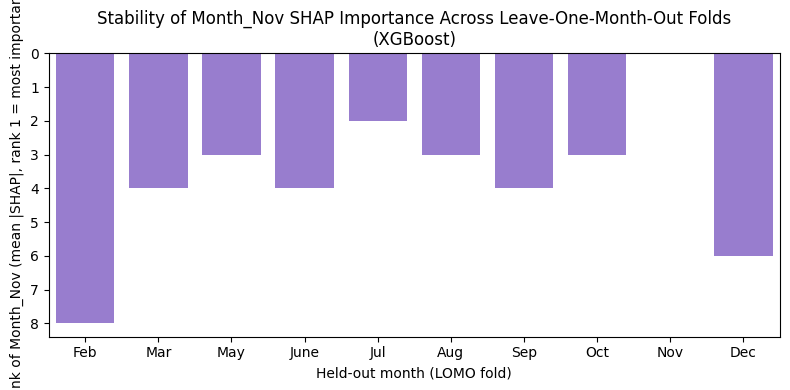

In [25]:
plot_df = nov_rank_valid.copy()
plot_df["Held_out_month"] = pd.Categorical(plot_df["Held_out_month"], categories=MONTH_ORDER, ordered=True)
plot_df = plot_df.sort_values("Held_out_month")

plt.figure(figsize=(8, 4))
sns.barplot(data=plot_df, x="Held_out_month", y="rank", color="mediumpurple")
plt.gca().invert_yaxis()
plt.ylabel("Rank of Month_Nov (mean |SHAP|, rank 1 = most important)")
plt.xlabel("Held-out month (LOMO fold)")
plt.title("Stability of Month_Nov SHAP Importance Across Leave-One-Month-Out Folds\n(XGBoost)")
plt.tight_layout()
plt.savefig("xgb_lomo_month_nov_rank_stability.png", dpi=200, bbox_inches="tight")
plt.show()


In [26]:
# RBO@k for LOMO SHAP rankings — top-k stability, not just full-rank correlation
def rbo(list1, list2, p=0.9):
    s, l = (list1, list2) if len(list1) <= len(list2) else (list2, list1)
    short_len, long_len = len(s), len(l)
    if short_len == 0:
        return 0.0
    x_k = 0
    rbo_sum = 0.0
    s_set, l_set = set(), set()
    for d in range(1, long_len + 1):
        if d <= short_len:
            s_set.add(s[d - 1])
        l_set.add(l[d - 1])
        x_k = len(s_set & l_set)
        rbo_sum += (p ** (d - 1)) * (x_k / d)
    rbo_ext = (1 - p) * rbo_sum
    if short_len < long_len:
        x_s = len(s_set & l_set)
        rbo_ext += (x_s * (1 - p) / short_len) * (p ** short_len) * (long_len - short_len) / long_len \
                   if short_len > 0 else 0
    return min(rbo_ext, 1.0)

def rbo_at_k(rank_df_a, rank_df_b, feature_col="feature", rank_col="rank", ks=(5, 10, None), p=0.9):
    order_a = rank_df_a.sort_values(rank_col)[feature_col].tolist()
    order_b = rank_df_b.sort_values(rank_col)[feature_col].tolist()
    rows = []
    for k in ks:
        la = order_a[:k] if k else order_a
        lb = order_b[:k] if k else order_b
        rows.append({"top_k": k if k else "all", "RBO": round(rbo(la, lb, p=p), 4), "p": p})
    return pd.DataFrame(rows)

# Compare each LOMO fold's SHAP ranking against XGBoost's own full-data chronological ranking
xgb_chrono_ranking = shap_importance_chrono  # already has columns: feature, mean_abs_shap, rank

rbo_rows = []
for fold_month in lomo_shap_all["Held_out_month"].unique():
    fold_rank = lomo_shap_all[lomo_shap_all["Held_out_month"] == fold_month]
    fold_scores = rbo_at_k(fold_rank, xgb_chrono_ranking, ks=(5, 10, None))
    fold_scores["Held_out_month"] = fold_month
    rbo_rows.append(fold_scores)

xgb_lomo_rbo = pd.concat(rbo_rows, ignore_index=True)
xgb_lomo_rbo.to_csv("xgb_lomo_rbo_at_10.csv", index=False)
xgb_lomo_rbo

,top_k,RBO,p,Held_out_month
0,5,0.2748,0.9,Feb
1,10,0.4417,0.9,Feb
2,all,0.7241,0.9,Feb
3,5,0.2879,0.9,Mar
4,10,0.4560,0.9,Mar
5,all,0.7307,0.9,Mar
6,5,0.2609,0.9,May
7,10,0.4377,0.9,May
8,all,0.7031,0.9,May
9,5,0.2879,0.9,June


## 3. Cross-architecture rank agreement under the out-of-time protocol

Spearman correlation between the RF and XGBoost SHAP rankings on the **chronological holdout**, mirroring the leakage-free comparison already reported in `XGboost.ipynb`, but now under out-of-time validation. Requires `06_RandomForest_Robustness.ipynb` to have been run first (reads `rf_chronological_shap_importance.csv`).

In [27]:
from scipy.stats import spearmanr
import os

rf_shap_path = "rf_chronological_shap_importance.csv"
if os.path.exists(rf_shap_path):
    rf_shap_chrono = pd.read_csv(rf_shap_path)
    merged = rf_shap_chrono.merge(shap_importance_chrono, on="feature", suffixes=("_rf", "_xgb"))
    rho, p = spearmanr(merged["rank_rf"], merged["rank_xgb"])
    print(f"Spearman rank correlation between RF and XGBoost SHAP rankings "
          f"(chronological holdout): rho = {rho:.3f}, p = {p:.4g}")
    merged.to_csv("xgb_vs_rf_shap_comparison_chronological.csv", index=False)
else:
    print(f"'{rf_shap_path}' not found - run 06_RandomForest_Robustness.ipynb first "
          f"to enable this cross-architecture comparison.")


Spearman rank correlation between RF and XGBoost SHAP rankings (chronological holdout): rho = 0.962, p = 4.594e-37


## 4. Bootstrap confidence intervals on the chronological holdout

In [28]:
N_BOOTSTRAPS = 1000
rng = np.random.default_rng(RANDOM_STATE)

y_test_arr = y_test_chrono.to_numpy()
y_prob_chrono = xgb_chrono.predict_proba(X_test_chrono_s)[:, 1]
y_pred_chrono_arr = xgb_chrono.predict(X_test_chrono_s)

boot_metrics = {"ROC_AUC": [], "PR_AUC": [], "F1": [], "MCC": []}
n = len(y_test_arr)

for _ in range(N_BOOTSTRAPS):
    idx = rng.integers(0, n, n)
    yt, yp, ypb = y_test_arr[idx], y_pred_chrono_arr[idx], y_prob_chrono[idx]
    if len(np.unique(yt)) < 2:
        continue
    boot_metrics["ROC_AUC"].append(roc_auc_score(yt, ypb))
    boot_metrics["PR_AUC"].append(average_precision_score(yt, ypb))
    boot_metrics["F1"].append(f1_score(yt, yp))
    boot_metrics["MCC"].append(matthews_corrcoef(yt, yp))

boot_summary = []
for metric, vals in boot_metrics.items():
    vals = np.array(vals)
    boot_summary.append({
        "Metric": metric,
        "Mean": round(vals.mean(), 4),
        "Std": round(vals.std(), 4),
        "CI95_low": round(np.percentile(vals, 2.5), 4),
        "CI95_high": round(np.percentile(vals, 97.5), 4),
        "N_bootstraps": len(vals),
    })

boot_summary_df = pd.DataFrame(boot_summary)
boot_summary_df.to_csv("xgb_chronological_bootstrap_ci.csv", index=False)
boot_summary_df


,Metric,Mean,Std,CI95_low,CI95_high,N_bootstraps
0,ROC_AUC,0.6353,0.0087,0.6192,0.6517,1000
1,PR_AUC,0.2964,0.0120,0.2748,0.3210,1000
2,F1,0.3755,0.0099,0.3567,0.3942,1000
3,MCC,0.1429,0.0132,0.1177,0.1699,1000


## 5. Save artifacts

In [29]:
joblib.dump(xgb_chrono, "shopping_model_xgb_chronological.pkl")
joblib.dump(scaler_chrono, "shopping_scaler_xgb_chronological.pkl")

print("Saved outputs:")
print(" - xgb_gridsearch_chronological.csv               (inner 5-fold grid search results)")
print(" - xgb_chronological_holdout_results.csv          (headline metrics, Oct-Dec holdout)")
print(" - xgb_confusion_matrix_chronological.png")
print(" - xgb_chronological_shap_importance.csv          (native TreeSHAP ranking, chronological model)")
print(" - xgb_lomo_results.csv                           (per-month LOMO performance)")
print(" - xgb_lomo_performance_summary.csv               (mean/SD across LOMO folds)")
print(" - xgb_lomo_shap_importance_all_months.csv        (full SHAP table, every LOMO fold)")
print(" - xgb_lomo_month_nov_rank_by_fold.csv            (Month_Nov SHAP rank per LOMO fold)")
print(" - xgb_lomo_month_nov_rank_stability.png")
print(" - xgb_vs_rf_shap_comparison_chronological.csv    (cross-architecture rank agreement, if RF notebook run first)")
print(" - xgb_chronological_bootstrap_ci.csv             (1,000-resample 95% CIs)")
print(" - shopping_model_xgb_chronological.pkl, shopping_scaler_xgb_chronological.pkl")


Saved outputs:
 - xgb_gridsearch_chronological.csv               (inner 5-fold grid search results)
 - xgb_chronological_holdout_results.csv          (headline metrics, Oct-Dec holdout)
 - xgb_confusion_matrix_chronological.png
 - xgb_chronological_shap_importance.csv          (native TreeSHAP ranking, chronological model)
 - xgb_lomo_results.csv                           (per-month LOMO performance)
 - xgb_lomo_performance_summary.csv               (mean/SD across LOMO folds)
 - xgb_lomo_shap_importance_all_months.csv        (full SHAP table, every LOMO fold)
 - xgb_lomo_month_nov_rank_by_fold.csv            (Month_Nov SHAP rank per LOMO fold)
 - xgb_lomo_month_nov_rank_stability.png
 - xgb_vs_rf_shap_comparison_chronological.csv    (cross-architecture rank agreement, if RF notebook run first)
 - xgb_chronological_bootstrap_ci.csv             (1,000-resample 95% CIs)
 - shopping_model_xgb_chronological.pkl, shopping_scaler_xgb_chronological.pkl
